In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv("Train_Data.csv")
TARGET = "Dropped_Course"
baseline_rate = df[TARGET].mean()
print(df.shape)
print(f"overall {TARGET} rate: {baseline_rate:.4f}")

(63464, 29)
overall Dropped_Course rate: 0.4144


# Numerical variables

## Prev_Course_Dropouts

count    63464.000000
mean         0.095991
std          0.448526
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: Prev_Course_Dropouts, dtype: float64


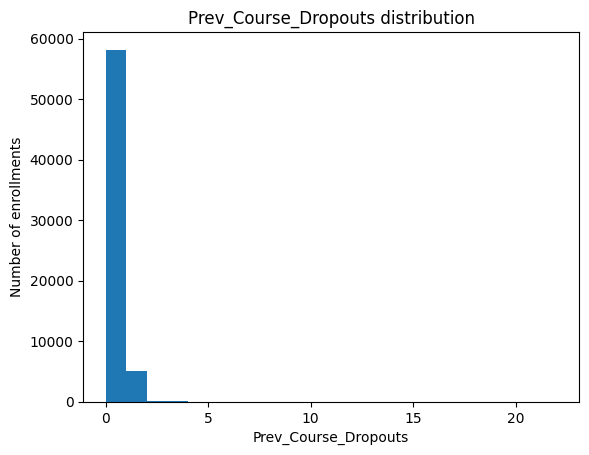

                          mean  count   pct
Prev_Course_Dropouts                       
0                     0.366046  58184  91.7
1                     0.974430   5084   8.0
2                     0.153846     65   0.1
3                     0.122449     49   0.1
4                     0.083333     12   0.0
5                     0.090909     11   0.0
6                     0.636364     11   0.0
11                    0.285714     35   0.1
13                    0.916667     12   0.0
21                    1.000000      1   0.0


In [2]:
col = "Prev_Course_Dropouts"
print(df[col].describe())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

**What can you infer about `Prev_Course_Dropouts`?**

1. `0` and `1` together account for 99.7% of rows (n=58,184 and n=5,084 respectively). The remaining values (2–21) total only n=196, split across 8 sparse bins — not statistically meaningful on their own.
2. The drop rate nearly triples between these two dominant values: 36.6% at `0` vs. 97.4% at `1`. This is the effect that matters for the analysis.

**Decision:** treat `Prev_Course_Dropouts` as informative only at `0` vs. `1`; exclude rows with values ≥2 from any effect estimate involving this variable, since n=196 is too small to support a reliable per-value rate.

## Returning_Client


Returning_Client
0    61742
1     1722
Name: count, dtype: int64
                      mean  count   pct
Returning_Client                       
0                 0.419261  61742  97.3
1                 0.239837   1722   2.7


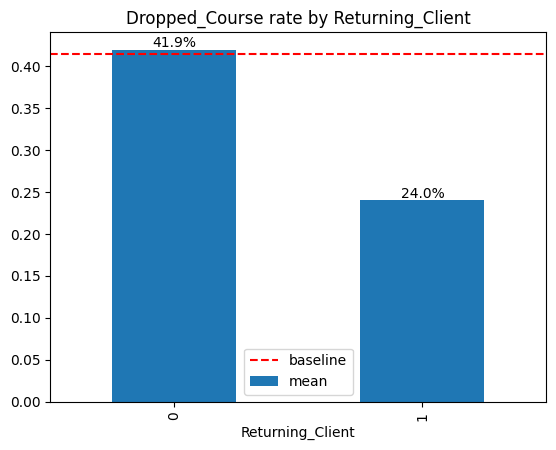

In [3]:
col = "Returning_Client"
print(df[col].value_counts())

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.legend()
plt.show()

table = pd.crosstab(df[col], df[TARGET])

**What can you infer about `Returning_Clients`?**

1. returning clients drop out much less than new ones — 24.0% vs. 41.9%. New clients are at almost identical to baseline, so we can infer a returning client is less likely to drop.

**Decision:** keep as is.

## Prev_Course_Attended

count    63464.000000
mean         0.122967
std          1.535201
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         61.000000
Name: Prev_Course_Attended, dtype: float64
missing: 0


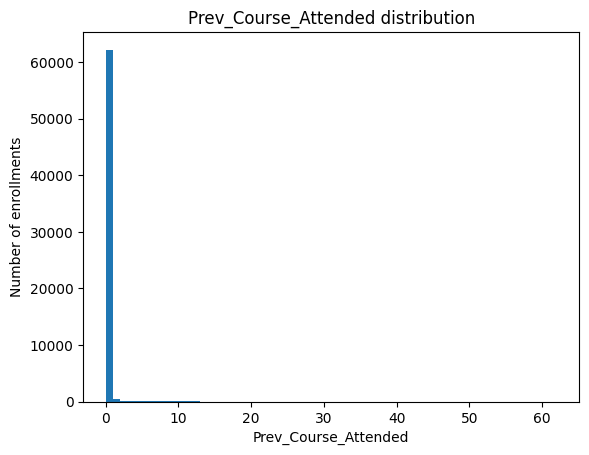

                          mean  count   pct
Prev_Course_Attended                       
0                     0.421384  62188  98.0
1                     0.068085    470   0.7
2                     0.058065    155   0.2
3                     0.056604    106   0.2
4                     0.096386     83   0.1
...                        ...    ...   ...
57                    0.000000      1   0.0
58                    0.500000      2   0.0
59                    0.000000      1   0.0
60                    0.000000      1   0.0
61                    0.000000      1   0.0

[62 rows x 3 columns]

0 vs 1+ grouped:
                          mean  count   pct
Prev_Course_Attended                       
False                 0.421384  62188  98.0
True                  0.073668   1276   2.0


In [4]:
col = "Prev_Course_Attended"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

has_attended = (df[col] > 0)
grouped = df.groupby(has_attended)[TARGET].agg(["mean", "count"])
grouped["pct"] = (grouped["count"] / len(df) * 100).round(1)
print("\n0 vs 1+ grouped:")
print(grouped)

**What can you infer about `Prev_Course_Attended`?**
1. Similar logic to `Prev_Course_Dropouts`: 98% of clients have a value of `0`. The remaining 2% are spread thin across 61 distinct values, many with n<5.
2. Drop rate falls from 42.1% to 7.4% once a client has attended at least one prior course — having attended before is strongly protective, making a client far less likely to drop.
**Decision**: In prev_dropouts, we can divide groups to 0, 1, other values. Here, its almost requrested to divide to 2 groups - '0' and other values.

## Registration_Days_Before

count    60798.000000
mean       102.894470
std        109.178824
min          0.000000
25%         19.000000
50%         65.000000
75%        150.000000
max        629.000000
Name: Registration_Days_Before, dtype: float64
missing: 2666 (4.20%)


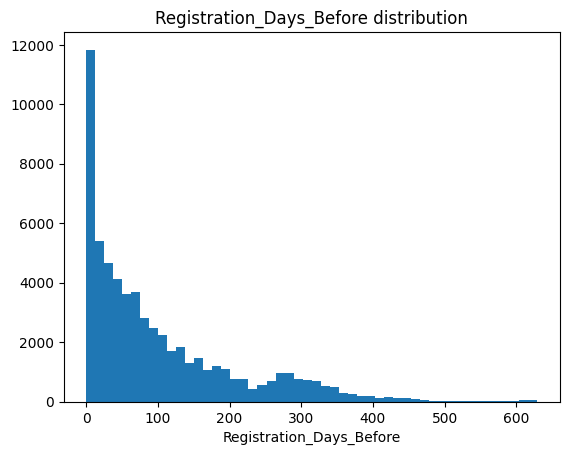

/var/folders/c5/h4k7d6vn4wq61cm8r8vwbvg80000gn/T/ipykernel_96924/3937886031.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])


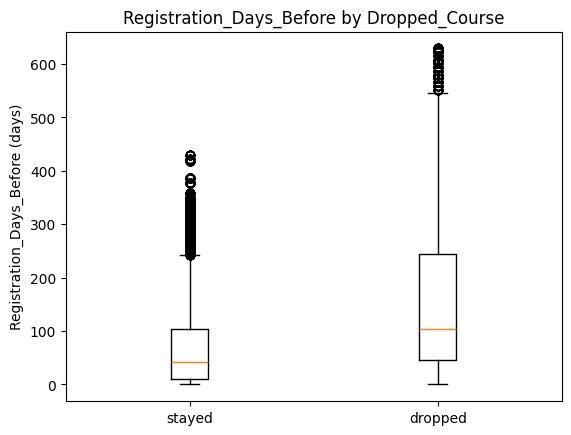

stayed: {'mean': 70.64140875133404, '50%': 43.0}
dropped: {'mean': 148.48046999047315, '50%': 104.0}
               mean  count   pct
has value  0.414356  60798  95.8
missing    0.415229   2666   4.2


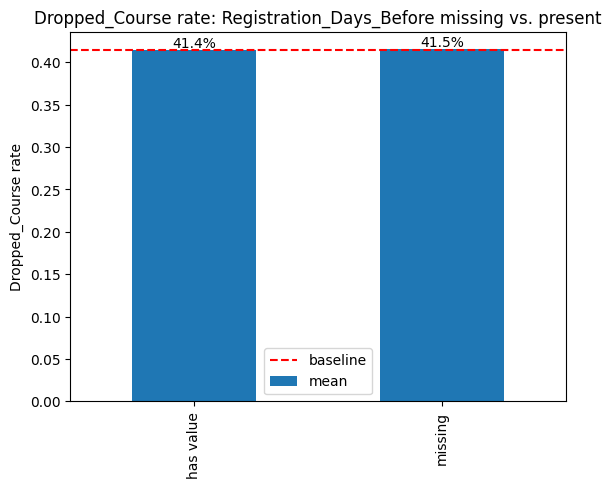

In [5]:
col = "Registration_Days_Before"
print(df[col].describe())
print("missing:", df[col].isna().sum(), f"({df[col].isna().mean():.2%})")

plt.hist(df[col].dropna(), bins=50)
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

dropped = df.loc[df[TARGET] == 1, col].dropna()
stayed = df.loc[df[TARGET] == 0, col].dropna()

plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])
plt.title(f"{col} by {TARGET}")
plt.ylabel(f"{col} (days)")
plt.show()

print("stayed:", stayed.describe()[["mean", "50%"]].to_dict())
print("dropped:", dropped.describe()[["mean", "50%"]].to_dict())

# is missingness itself related to the target? -> decides imputation strategy
rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

ax = rate_by_missing["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_missing["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate: {col} missing vs. present")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Registration_Days_Before`?**

1. **Histogram — right-skewed distribution.** Mean (103) is well above the median (65), and the max reaches 629. Most clients register between 19 and 150 days ahead, with a long tail of a few registering much earlier (max = 629). This tail stretches the mean to the right, and makes it less reliable. Also, intuitivly, it seems unreasonable to register to a course almost 2 years prior to its start date. 
2. **Boxplot — stayed vs. dropped.** Clients who registered a "long" period in advance were more likely to drop, rather than ones who registered later - median 104 days (mean 148.5) for dropped vs. median 43 days (mean 70) for those who stayed. 
3. **Missing values bar chart.** 4.2% of rows (n=2,666) have no value. Their drop rate (41.5%) sits right on the baseline (41.4%), same as non-missing or has-value rows — both bars line up with the baseline line, so missingness itself has no significant effect

**Decision:** we're keeping this one as a numeric predictor — the stayed-vs-dropped gap is real, not noise. When we describe it later, we'll use the median rather than the mean, since the skew makes the mean misleading. The 629-day outlier is worth a second look in Stage 2, but nothing to act on yet. And since missing values don't line up with the target at all, perhaps filling with a median will do.

## Waiting_List_Days

count    63464.000000
mean         3.983676
std         23.195495
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        391.000000
Name: Waiting_List_Days, dtype: float64
missing: 0


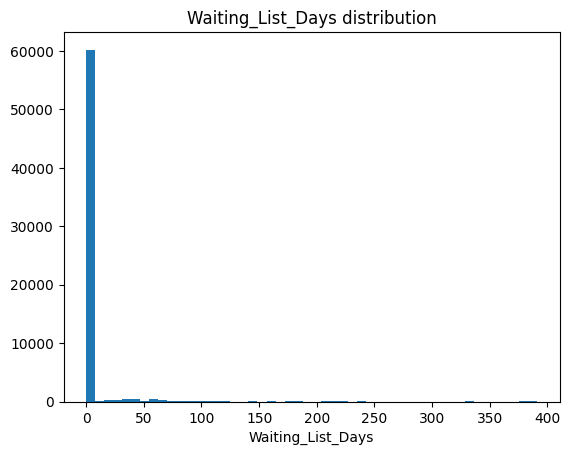

                   mean  count   pct
0 (no wait)    0.399674  60089  94.7
1+ (any wait)  0.676444   3375   5.3


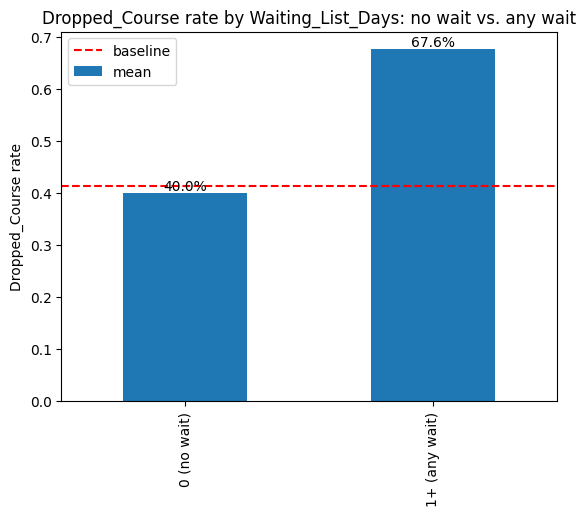


non-zero waiting days: {'mean': 74.90962962962963, '50%': 50.0}


In [6]:
col = "Waiting_List_Days"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=50)
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

dropped = df.loc[df[TARGET] == 1, col]
stayed = df.loc[df[TARGET] == 0, col]

on_waitlist = (df[col] > 0)
rate_by_waitlist = df.groupby(on_waitlist)[TARGET].agg(["mean", "count"])
rate_by_waitlist.index = ["0 (no wait)", "1+ (any wait)"]
rate_by_waitlist["pct"] = (rate_by_waitlist["count"] / len(df) * 100).round(1)
print(rate_by_waitlist)

ax = rate_by_waitlist["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_waitlist["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}: no wait vs. any wait")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

print("\nnon-zero waiting days:", df.loc[on_waitlist, col].describe()[["mean", "50%"]].to_dict())

**What can you infer about `Waiting_List_Days`?**

1. Above 94% of clients have `0` waiting days. This turns the question to a binary state - did a client wait or no? - zero vs non zero waiting days. 
2. Grouping by non-zero values creates a comperable group. Drop rate for zero wait clients is below 40% (mean), where any wait clients are at a much higher rate - above 67%, a 27% difference.while n=3375 sits at above 5% - not insignificant number. also, the mean of typical wait itself is almost 75 days - not a one day wait - fairly long.

**Decision:** we'll treat this one as informative mainly through the `0` vs. `1+` split. The exact number of days beyond that adds some spread, but it's not where the main effect lives.

## Registration_Changes

count    63464.000000
mean         0.180039
std          0.592577
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: Registration_Changes, dtype: float64
missing: 0


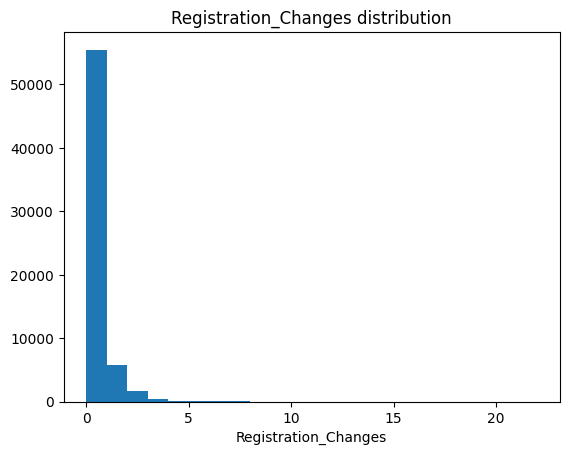

                          mean  count   pct
Registration_Changes                       
0                     0.450845  55478  87.4
1                     0.140554   5706   9.0
2                     0.216775   1693   2.7
3                     0.178674    347   0.5
4                     0.234043    141   0.2
5                     0.294118     34   0.1
6                     0.347826     23   0.0
7                     0.066667     15   0.0
8                     0.250000      8   0.0
9                     0.250000      4   0.0
10                    0.000000      1   0.0
11                    0.000000      1   0.0
12                    0.000000      1   0.0
13                    0.000000      3   0.0
14                    0.250000      4   0.0
15                    0.000000      2   0.0
17                    0.000000      1   0.0
20                    0.000000      1   0.0
21                    0.000000      1   0.0

bucketed 0 / 1 / 2+:
                          mean  count   pct
Registrati

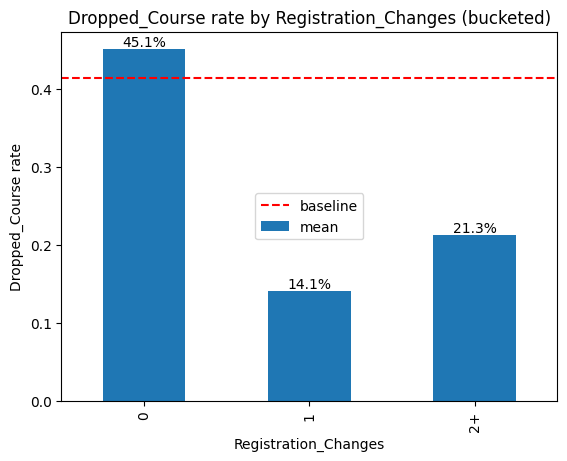

In [7]:
col = "Registration_Changes"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

bucket = pd.cut(df[col], bins=[-1, 0, 1, 100], labels=["0", "1", "2+"])
rate_by_bucket = df.groupby(bucket, observed=True)[TARGET].agg(["mean", "count"])
rate_by_bucket["pct"] = (rate_by_bucket["count"] / len(df) * 100).round(1)
print("\nbucketed 0 / 1 / 2+:")
print(rate_by_bucket)

ax = rate_by_bucket["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_bucket["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (bucketed)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Registration_Changes`?**
1. Still, we see a pattern where a mass of the data (above 87%) sits at `0`, with a right thin tail up to 21. Value `1` alone has n=5,706 (9%) — large enough to stand on its own — while above value `2` (2.7% of rows) counts fall off fast (3→347, 4→141, 5→34, ... down to n=1 by value 21). Grouping everything ≥2 together creates a more solid group (3.6%)

2. The bar chart shows us that '0' sits above baseline (45%), 1 drops well below at 14%, and ≥2 group shows a slight bump, and overall higher percentage - 21%, but still under baseline. Practically, this means a client that performs any changes to their registration is less likely to drop.

**Conclusion**: Group by 0/1/≥2. 

## Pre_Course_Supports_Tickets

count    63464.000000
mean         0.513330
std          0.763563
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: Pre_Course_Supports_Tickets, dtype: float64
missing: 0


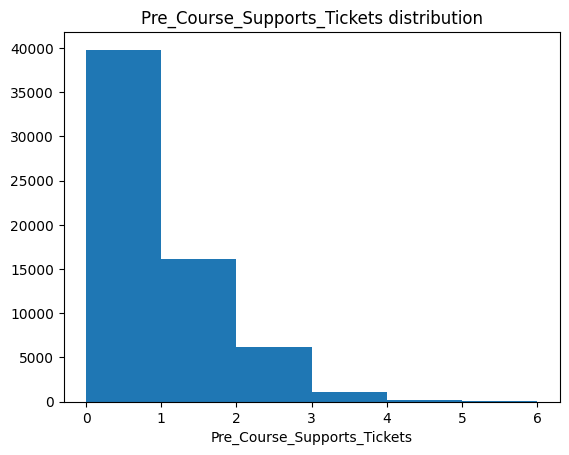

                                 mean  count   pct
Pre_Course_Supports_Tickets                       
0                            0.544364  39830  62.8
1                            0.195439  16138  25.4
2                            0.201191   6213   9.8
3                            0.174603   1134   1.8
4                            0.112782    133   0.2
5                            0.000000     16   0.0

bucketed 0 vs 1+:
                      mean  count   pct
0 (no tickets)    0.544364  39830  62.8
1+ (any tickets)  0.195354  23634  37.2


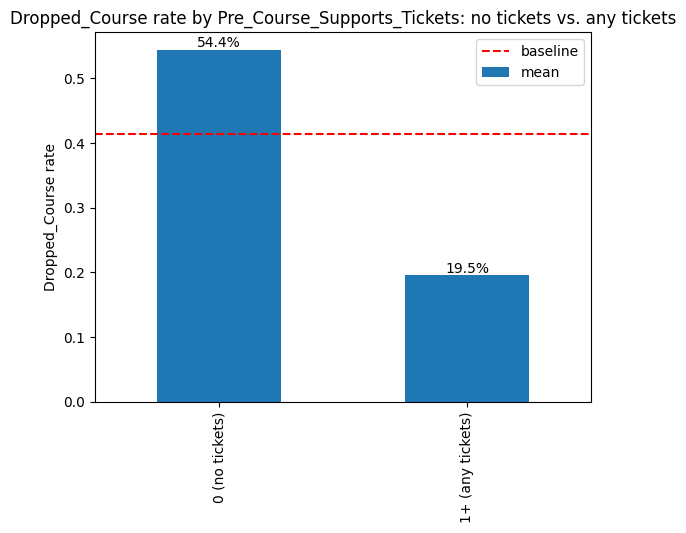

In [8]:
col = "Pre_Course_Supports_Tickets"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

had_ticket = (df[col] > 0)
rate_by_ticket = df.groupby(had_ticket)[TARGET].agg(["mean", "count"])
rate_by_ticket.index = ["0 (no tickets)", "1+ (any tickets)"]
rate_by_ticket["pct"] = (rate_by_ticket["count"] / len(df) * 100).round(1)
print("\nbucketed 0 vs 1+:")
print(rate_by_ticket)

ax = rate_by_ticket["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_ticket["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}: no tickets vs. any tickets")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Pre_Course_Supports_Tickets`?**

1. **Histogram — most clients open 0 or 1 ticket.** No missing values. Range is only 0–5 (much narrower than the other count variables), with 62.8% at `0` (n=39,830) and the rest spread across 1–5. Per-value rates are 0→54.4%, 1→19.5%, 2→20.1%, 3→17.5%, 4→11.3%, 5→0% (n=16) — every value from 1 up sits in a similar low range, with no distinct dip-then-rebound like `Registration_Changes` had. That's why this one is a clean 2-way split, not 3.
2. **Bar chart — bucketed 0 vs. 1+ against baseline.** `0` sits well above baseline (54.4% vs. 41.4%), while `1+` drops to 19.5% — both buckets are large (n=39,830 and n=23,634), so the gap is solid, not noise.

**Decision:** keep `Pre_Course_Supports_Tickets` bucketed as `0` vs. `1+` (opened any support ticket before the course, or not) — same shape as `Waiting_List_Days`. Having filed a ticket at all looks protective, in the same "engagement, not friction" direction as `Registration_Changes`.

# Tier 2 — dirty categoricals (text cleaning needed)

These columns have inflated cardinality from stray characters, whitespace, and case variants (e.g. `" PRT"`, `"PRT#"`, `"prt"` are all the same value). Clean inline before analyzing.

## Origin_Country

raw unique: 721 -> cleaned unique: 154
country_clean
PRT        26429
FRA         6961
DEU         4400
ESP         3896
GBR         3514
ITA         2726
BRA         1402
BEL         1324
NLD         1222
USA         1072
CHN         1054
CHE          935
IRL          808
AUT          782
MISSING      557
ISR          542
SWE          512
POL          462
RUS          348
AGO          309
Name: count, dtype: int64
                   mean  count   pct
country_clean                       
PRT            0.637784  26429  41.6
FRA            0.172820   6961  11.0
DEU            0.167045   4400   6.9
ESP            0.273101   3896   6.1
GBR            0.278031   3514   5.5
ITA            0.358767   2726   4.3
BRA            0.380171   1402   2.2
BEL            0.191843   1324   2.1
NLD            0.199673   1222   1.9
USA            0.223881   1072   1.7
CHN            0.427894   1054   1.7
CHE            0.227807    935   1.5
IRL            0.314356    808   1.3
AUT            0.159847   

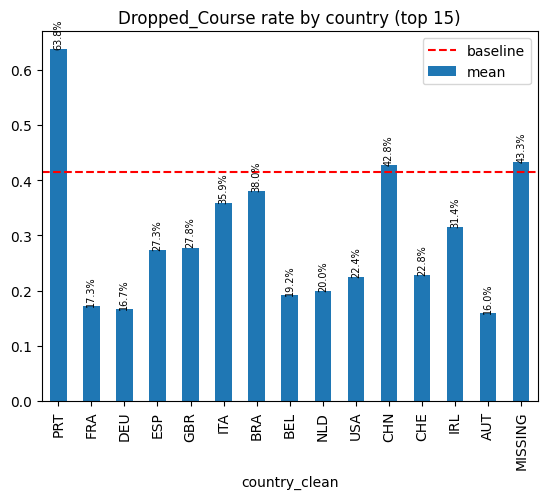

chi2=10869.46, dof=153, p=0.000e+00


In [9]:
col = "Origin_Country"
raw = df[col].astype(str)
cleaned = raw.str.upper().str.replace(r"[^A-Z]", "", regex=True)
cleaned = cleaned.replace("CN", "CHN")
cleaned = cleaned.where(df[col].notna(), "MISSING")
df["country_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["country_clean"].nunique())

vc = df["country_clean"].value_counts()
print(vc.head(20))

top = vc.head(15).index
rate_by_country = df[df["country_clean"].isin(top)].groupby("country_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_country["pct"] = (rate_by_country["count"] / len(df) * 100).round(1)
print(rate_by_country)

ax = rate_by_country["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_country["mean"]], fontsize=7, rotation=90)
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by country (top 15)")
plt.legend()
plt.show()

table = pd.crosstab(df["country_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

**What can you infer about `Origin_Country`?**

1. **Cleaning.** 721 raw values collapse to 154 real country codes once junk characters/casing are stripped — same corruption pattern as the other dirty categoricals.
2. **Bar chart — rate by country (top 15 by count).** `PRT` alone is 41.6% of all rows (n=26,429) and sits far above baseline at 63.8%. Nearly every other well-populated country sits clearly *below* baseline instead: `FRA` (11.0%, n=6,961) at 17.3%, `DEU` (6.9%) at 16.7%, `ESP` (6.1%) at 27.3%, `GBR` (5.5%) at 27.8%, `BEL`, `NLD`, `AUT` all in the 16-20% range. `CHN` (1.7%) and `MISSING` (0.9%) are the exceptions that sit near baseline (42.8% and 43.3%). chi2=10869.46, dof=153, p≈0 — not ambiguous.

**Decision:** country clearly relates to drop behavior, but the effect is dominated by one giant category (`PRT`) running hot while most of the rest run cold — this isn't a simple high/low split, it's genuine per-country variation across 154 levels. That's too many categories to one-hot without exploding dimensionality for 63k rows, so we'll use smoothed target encoding in Stage 2 (per the skill's formula) rather than one-hot or plain per-country mean — `PRT` has enough rows (26,429) that its encoded value should barely move from its raw 63.8%, while the long tail of small countries should shrink toward the ~41.4% global baseline instead of keeping noisy small-n estimates.

# Categorical / text variables

Includes dirty text columns needing cleaning (stray characters, whitespace, case variants — e.g. `" PRT"`, `"PRT#"`, `"prt"` are all the same value) and true categorical/ID columns.

## Company_ID

             mean  count   pct
missing  0.424848  60344  95.1
present  0.212179   3120   4.9


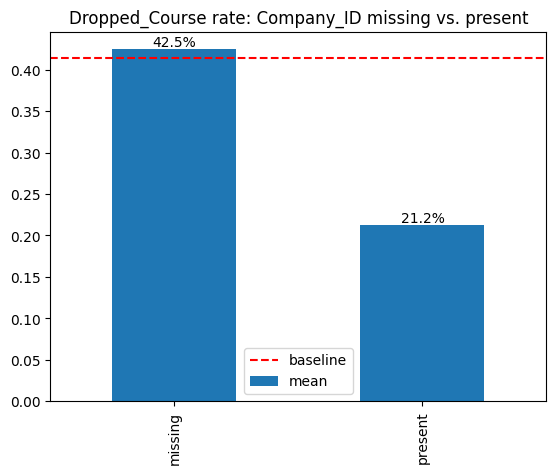

In [11]:
has_company = df['Company_ID'].notna()
rate_by_flag = df.groupby(has_company)[TARGET].agg(['mean', 'count'])
rate_by_flag.index = ['missing', 'present']
rate_by_flag["pct"] = (rate_by_flag["count"] / len(df) * 100).round(1)
print(rate_by_flag)

ax = rate_by_flag['mean'].plot(kind='bar')
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_flag["mean"]])
plt.axhline(baseline_rate, color='red', linestyle='--', label='baseline')
plt.title(f"{TARGET} rate: Company_ID missing vs. present")
plt.legend()
plt.show()

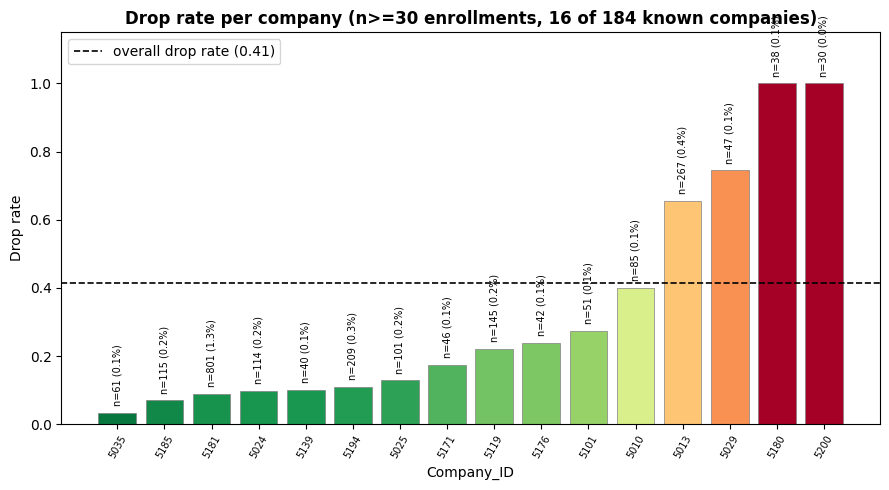

companies with n>=30: 16 of 184 known companies, covering 2192 rows (3.5% of all rows)
            mean       count
count  16.000000   16.000000
mean    0.333426  137.000000
std     0.330490  189.260667
min     0.032787   30.000000
25%     0.099123   45.000000
50%     0.197301   73.000000
75%     0.463858  122.500000
max     1.000000  801.000000


In [12]:
present = df[df['Company_ID'].notna()] # Filter out rows where Company_ID is missing
base = df["Dropped_Course"].mean() # Calculate the overall average drop rate

# Keep only companies with n>=30 enrollemnts, using Central Limit Theorom
counts = present['Company_ID'].value_counts() # Count enrollments per company
big = counts[counts >= 30].index
r = (present[present['Company_ID'].isin(big)] # Filter for 'big' companies
     .groupby('Company_ID')[TARGET] # Group by Company_ID
     .agg(['mean', 'count']) # Calculate mean drop rate and count of enrollments
     .sort_values('mean')) # Sort by mean drop rate for visualization
r['pct'] = (r['count'] / len(df) * 100).round(1) # each company's share of all enrollments

fig, ax = plt.subplots(figsize=(9, 5)) # Create a plot figure and axes
colors = plt.cm.RdYlGn_r(r['mean'].values) # Assign colors based on drop rate (green for low, red for high)
ax.bar(range(len(r)), r['mean'].values, color=colors, edgecolor='gray', lw=0.5) # Create the bar chart
ax.axhline(base, ls='--', color='black', lw=1.2,
           label=f'overall drop rate ({base:.2f})') # Add a horizontal line for the overall average drop rate

# Annotate each bar with its sample size ('n=...') and share of all enrollments ('%')
for i, (idx, row) in enumerate(r.iterrows()):
    ax.text(i, row['mean'] + 0.02, f"n={int(row['count'])} ({row['pct']}%)", # Place text annotation
            ha='center', va='bottom', fontsize=7, rotation=90) # Style the annotation

ax.set_xticks(range(len(r))) # Set x-axis ticks
ax.set_xticklabels([int(x) for x in r.index], rotation=60, fontsize=7) # Label x-axis with Company_ID and rotate labels
ax.set_ylabel('Drop rate'); ax.set_xlabel('Company_ID'); ax.set_ylim(0, 1.15) # Set y-axis label, x-axis label, and y-axis limits
ax.set_title(f'Drop rate per company (n>=30 enrollments, {len(big)} of {present["Company_ID"].nunique()} known companies)',
             fontweight='bold') # Set plot title
ax.legend() # Display the legend
plt.tight_layout(); plt.show()
print(f"companies with n>=30: {len(big)} of {present['Company_ID'].nunique()} known companies, covering {r['count'].sum()} rows ({r['count'].sum()/len(df)*100:.1f}% of all rows)")
print(r[['mean','count']].describe())


**What can you infer about `Company_ID`?**

1. **Bar chart — missing vs. present.** Rows with no `Company_ID` (95.1%, n=60,344) drop at 42.5%, essentially the dataset baseline. Rows with a `Company_ID` (4.9%, n=3,120) drop at 21.2% — half the rate. Missingness itself is strongly informative, not MCAR.
2. **Bar chart — per-company rate, n≥30 only.** Only 16 of the 184 known companies clear a 30-enrollment threshold, covering 2,192 rows (3.5% of the dataset). Among those 16, drop rates range from 3.3% to 100%, mean 33.3%, std 33.0% — that's enormous spread for companies that are all "has a `Company_ID`." Knowing *which* company, not just whether one exists, carries real signal.

**Decision:** treat presence of `Company_ID` as its own feature (`has_company_id`) — going through a formal company channel roughly halves the drop rate. But the per-company spread (3%–100%) says the flag alone leaves signal on the table for the ~5% of rows that do have an ID; in Stage 2 we should consider a smoothed target/frequency encoding of the ID itself (per the skill's smoothing formula) rather than one-hotting 184 sparse IDs, since most companies fall well under n=30.

# Date variables

## Course_Start_Date

count                            63464
mean     2016-06-23 05:17:23.287533056
min                2015-07-01 00:00:00
25%                2016-02-13 00:00:00
50%                2016-07-01 00:00:00
75%                2016-11-11 00:00:00
max                2017-04-26 00:00:00
Name: Course_Start_Date, dtype: object
                       mean  count  pct
Course_Start_Date                      
2015-07-01         0.671674   1398  2.2
2015-08-01         0.496774   2480  3.9
2015-09-01         0.437234   3529  5.6
2015-10-01         0.390136   3386  5.3
2015-11-01         0.243725   1235  1.9
2015-12-01         0.403869   1654  2.6
2016-01-01         0.321114   1364  2.1
2016-02-01         0.392240   2371  3.7
2016-03-01         0.363756   3046  4.8
2016-04-01         0.432182   3561  5.6
2016-05-01         0.390642   3676  5.8
2016-06-01         0.438440   3923  6.2
2016-07-01         0.333120   3131  4.9
2016-08-01         0.369153   3378  5.3
2016-09-01         0.404805   3871  6.1
2016-10-

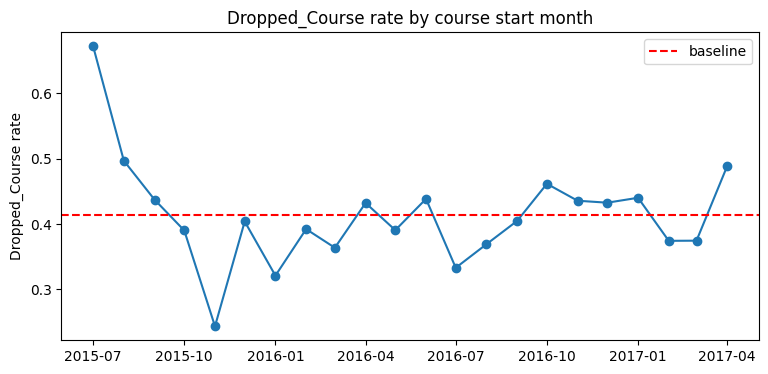

In [13]:
col = "Course_Start_Date"
df[col] = pd.to_datetime(df[col])
print(df[col].describe())

monthly = df.set_index(col).resample("MS")[TARGET].agg(["mean", "count"])
monthly["pct"] = (monthly["count"] / len(df) * 100).round(1)
print(monthly)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly["mean"], marker="o")
ax.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
ax.set_ylabel(f"{TARGET} rate")
ax.set_title(f"{TARGET} rate by course start month")
ax.legend()
plt.show()

**What can you infer about `Course_Start_Date`?**

1. **`describe()`.** Dates run from 2015-07-01 to 2017-04-26 (~22 months), median 2016-07-01 — full range is covered, no obvious corrupted dates.
2. **Rate-by-month line chart.** The very first month (2015-07, n=1,398, 2.2% of rows) is a sharp outlier at 67.2% drop rate — well above every other month. After that, monthly rates settle into a 24.4%–48.9% band with no clean monotonic trend: a trough at 2015-11 (24.4%, n=1,235) and peaks around 2016-10 (46.1%, n=4,219) and 2017-04 (48.9%, n=3,264). Looks like mild seasonality/noise rather than a strong linear time trend.

**Decision:** keep the date parsed to datetime (done). The 2015-07 spike is worth a second look in Stage 2 — it's early in the dataset's window and could reflect a ramp-up period (fewer, less-typical early clients) rather than a seasonal effect; not touching it in Stage 1. For Stage 2, a derived month-of-year or quarter feature looks more promising than the raw date, since the fluctuation doesn't look linear in time.

## Client_Category

raw unique: 505 -> cleaned unique: 8
client_category_clean
SAAS SOFTWARE HOUSES       29257
TRADITIONAL IT TELECOMM    14392
BIG TECH MULTINATIONALS    11909
FINTECH BANKING             4672
INDUSTRIAL TECH IOT         2603
NONPROFIT EDUTECH            465
DEFENSE GOVTECH              164
UNKNOWN                        2
Name: count, dtype: int64
                             mean  count   pct
client_category_clean                         
SAAS SOFTWARE HOUSES     0.360119  29257  46.1
TRADITIONAL IT TELECOMM  0.428016  14392  22.7
BIG TECH MULTINATIONALS  0.683685  11909  18.8
FINTECH BANKING          0.172517   4672   7.4
INDUSTRIAL TECH IOT      0.216289   2603   4.1
NONPROFIT EDUTECH        0.116129    465   0.7
DEFENSE GOVTECH          0.219512    164   0.3
UNKNOWN                  1.000000      2   0.0


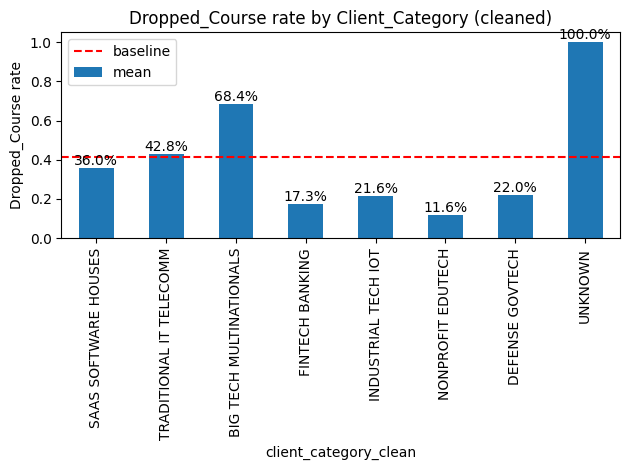

chi2=5671.19, dof=7, p=0.000e+00


In [14]:
col = "Client_Category"
raw = df[col].astype(str)

# same clean_text pattern as Origin_Country, but keep spaces (categories are multi-word)
cleaned = raw.str.upper().str.replace(r"[^A-Z\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
df["client_category_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["client_category_clean"].nunique())

vc = df["client_category_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("client_category_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["client_category_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

**What can you infer about `Client_Category`?**

1. **Cleaning.** 505 raw values collapse to 8 real categories once junk chars are stripped — same corruption pattern as `Origin_Country`.
2. **Bar chart — rate by category.** Big spread: `NONPROFIT EDUTECH` (0.7%, n=465) is lowest at 11.6%, `BIG TECH MULTINATIONALS` (18.8%, n=11,909) is highest among the well-populated groups at 68.4% — well above the ~41% baseline. `FINTECH BANKING` (7.4%, n=4,672) and `INDUSTRIAL TECH IOT` (4.1%, n=2,603) sit low, around 17–22%. `UNKNOWN` is n=2 at 100% — noise, not signal. chi2=5671.19, dof=7, p≈0 — effect is large and obvious from the table, no ambiguity to resolve with a test.

**Decision:** keep as a categorical predictor — business segment clearly relates to cancellation behavior (Big Tech Multinationals drop nearly 2x as often as Fintech/Industrial clients). Only 8 clean categories, so one-hot encoding is appropriate here per the cardinality rule, not target encoding. The `UNKNOWN` bucket (n=2) is too small to interpret on its own; fold it into a general "OTHER/MISSING" bucket in Stage 2 rather than giving it its own one-hot column.

## Payment_Terms

raw unique: 236 -> cleaned unique: 5
payment_terms_clean
PAY UPON START           51751
PREPAID NONREFUNDABLE    10698
MISSING                    792
UNKNOWN                    214
REFUNDABLE DEPOSIT           9
Name: count, dtype: int64
                           mean  count   pct
payment_terms_clean                         
PAY UPON START         0.294390  51751  81.5
PREPAID NONREFUNDABLE  0.997757  10698  16.9
MISSING                0.367424    792   1.2
UNKNOWN                0.443925    214   0.3
REFUNDABLE DEPOSIT     0.444444      9   0.0


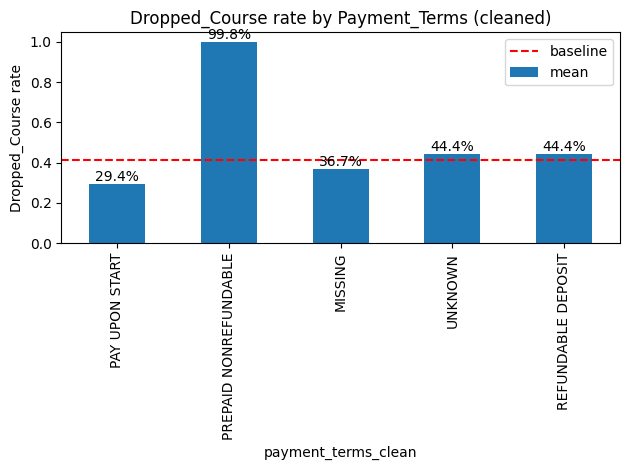

chi2=18081.48, dof=4, p=0.000e+00


In [15]:
col = "Payment_Terms"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
# blank after stripping (e.g. raw "?") and true NaN both mean no real answer given
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["payment_terms_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["payment_terms_clean"].nunique())

vc = df["payment_terms_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("payment_terms_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["payment_terms_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

**What can you infer about `Payment_Terms`?**

1. **Cleaning.** 236 raw values collapse to 5 categories (incl. `MISSING` for blank/NaN).
2. **Bar chart — rate by category.** `PAY UPON START` is 81.5% of rows (n=51,751) at a normal-looking 29.4% drop rate. `PREPAID NONREFUNDABLE` is 16.9% (n=10,698) but drops at **99.8%** — almost every single row in this category is a drop. `MISSING` (1.2%), `UNKNOWN` (0.3%), `REFUNDABLE DEPOSIT` (n=9) all sit near baseline (37–44%). chi2=18081.48, p≈0.

**Decision:** the `PREPAID NONREFUNDABLE` near-100% rate is the strongest single effect seen in any variable so far, and it's suspicious rather than just "great" — a non-refundable prepayment should structurally *discourage* cancellation (no financial upside to dropping), yet it correlates with cancellation almost perfectly. That pattern smells like a possible labeling/process artifact (e.g. this payment term only gets recorded after a drop is processed) rather than a genuine pre-course predictor, and it's the kind of near-deterministic relationship worth flagging as a leakage risk before it goes into a model in Stage 2. Keeping the column and the finding documented here, but this needs a closer look (e.g. checking whether `Payment_Terms` is set at registration time or after the fact) before trusting it as a feature.

## Enrollment_Type

raw unique: 298 -> cleaned unique: 5
enrollment_type_clean
GENERAL ADMISSION             45199
AFFILIATED ADMISSION          15034
CONTRACTUAL AGREEMENT          2272
MISSING                         719
ORGANIZATIONAL ARRANGEMENT      240
Name: count, dtype: int64
                                mean  count   pct
enrollment_type_clean                            
GENERAL ADMISSION           0.451957  45199  71.2
AFFILIATED ADMISSION        0.296262  15034  23.7
CONTRACTUAL AGREEMENT       0.482394   2272   3.6
MISSING                     0.411683    719   1.1
ORGANIZATIONAL ARRANGEMENT  0.104167    240   0.4


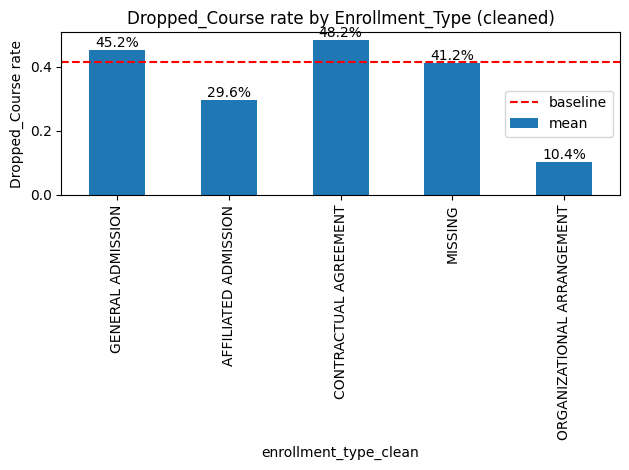

chi2=1265.85, dof=4, p=8.426e-273
Enrollment_Type
False    0.414423
True     0.411683
Name: Dropped_Course, dtype: float64


In [16]:
col = "Enrollment_Type"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["enrollment_type_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["enrollment_type_clean"].nunique())

vc = df["enrollment_type_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("enrollment_type_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["enrollment_type_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

# is missingness itself related to the target?
print(df.groupby(df[col].isna())[TARGET].mean())

**What can you infer about `Enrollment_Type`?**

1. **Cleaning.** 298 raw values collapse to 5 categories.
2. **Bar chart — rate by category.** Wide spread: `ORGANIZATIONAL ARRANGEMENT` (0.4%, n=240) is lowest at 10.4%, `CONTRACTUAL AGREEMENT` (3.6%, n=2,272) is highest at 48.2%. The two dominant categories split too: `GENERAL ADMISSION` (71.2%, n=45,199) sits above baseline at 45.2%, `AFFILIATED ADMISSION` (23.7%, n=15,034) sits well below at 29.6%. chi2=1265.85, dof=4, p=8.4e-273.
3. **Missingness check.** Present-rate 41.4% vs. missing-rate 41.2% — essentially identical to baseline. Missingness itself carries no signal here (unlike `Company_ID`).

**Decision:** keep as a categorical predictor — enrollment method clearly relates to drop behavior (General Admission vs. Affiliated Admission alone is a 15-point gap). Since missingness looks MCAR-like, the existing `MISSING`-as-its-own-category treatment from the cleaning step is fine as-is; no need for a separate `has_x` flag the way `Company_ID` needed one.

## Submission_Source

raw unique: 328 -> cleaned unique: 6
submission_source_clean
B2B PLATFORMS RESELLERS          54286
DIRECT WEBSITE REGISTRATION       5164
DEDICATED SALES TEAM              2853
MISSING                            790
UNKNOWN                            224
GOVERNMENT PROCUREMENT SYSTEM      147
Name: count, dtype: int64
                                   mean  count   pct
submission_source_clean                             
B2B PLATFORMS RESELLERS        0.446119  54286  85.5
DIRECT WEBSITE REGISTRATION    0.177382   5164   8.1
DEDICATED SALES TEAM           0.240449   2853   4.5
MISSING                        0.453165    790   1.2
UNKNOWN                        0.415179    224   0.4
GOVERNMENT PROCUREMENT SYSTEM  0.190476    147   0.2


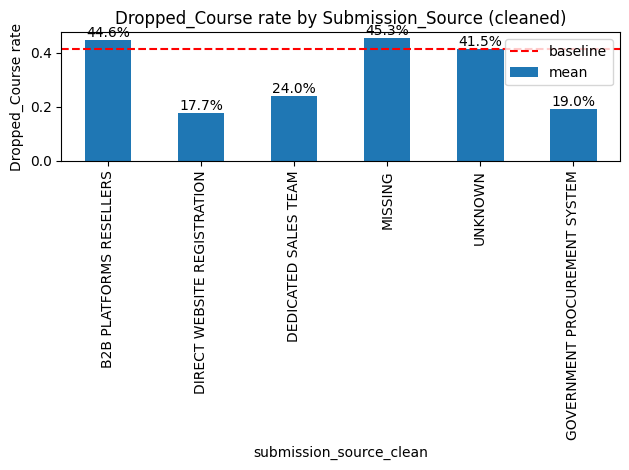

chi2=1811.52, dof=5, p=0.000e+00
Submission_Source
False    0.414006
True     0.454545
Name: Dropped_Course, dtype: float64


In [17]:
col = "Submission_Source"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["submission_source_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["submission_source_clean"].nunique())

vc = df["submission_source_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("submission_source_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["submission_source_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

print(df.groupby(df[col].isna())[TARGET].mean())

**What can you infer about `Submission_Source`?**

1. **Cleaning.** 328 raw values collapse to 6 categories.
2. **Bar chart — rate by category.** `B2B PLATFORMS RESELLERS` dominates at 85.5% of rows (n=54,286) with an above-baseline 44.6% drop rate. The smaller, more curated channels all drop far less: `DIRECT WEBSITE REGISTRATION` (8.1%, n=5,164) at 17.7%, `DEDICATED SALES TEAM` (4.5%, n=2,853) at 24.0%, `GOVERNMENT PROCUREMENT SYSTEM` (0.2%, n=147) at 19.0%. chi2=1811.52, dof=5, p≈0.
3. **Missingness check.** Present-rate 41.4% vs. missing-rate 45.5% - close enough to baseline (and missing is only n=790, 1.2% of rows) that this doesn't look like a strong missingness-target signal.

**Decision:** keep as a categorical predictor - self-service/reseller-driven registrations (B2B Platforms Resellers) drop noticeably more than human-mediated channels (Dedicated Sales Team, Direct Website). Missingness is close to baseline with low n, so the existing `MISSING`-category treatment from cleaning is sufficient; no separate flag needed.

In [18]:
col = "NEXT_COLUMN"